Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).

Handle missing values, if any.

Explore the dataset to understand its structure and attributes.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity,euclidean_distances

In [3]:
df = pd.read_csv('anime.csv')

In [4]:
df.shape

(12294, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [7]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [8]:
df.isnull().sum().sum()/df.size*100

np.float64(0.36835622487159825)

The missing value percentage is less than 5%. So i am going to drop the rows with missing values

In [9]:
df.dropna(subset=['genre','type','rating'],inplace=True)

In [10]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,0
members,0


In [19]:
df.describe()

,anime_id,rating,members
count,12017.000000,12017.000000,1.201700e+04
mean,13638.001165,6.478264,1.834888e+04
std,11231.076675,1.023857,5.537250e+04
min,1.000000,1.670000,1.200000e+01
25%,3391.000000,5.890000,2.250000e+02
50%,9959.000000,6.570000,1.552000e+03
75%,23729.000000,7.180000,9.588000e+03
max,34519.000000,10.000000,1.013917e+06


In [11]:
df.name.unique()

array(['Kimi no Na wa.', 'Fullmetal Alchemist: Brotherhood', 'Gintama°',
       ..., 'Violence Gekiga David no Hoshi',
       'Violence Gekiga Shin David no Hoshi: Inma Densetsu',
       'Yasuji no Pornorama: Yacchimae!!'], dtype=object)

In [12]:
len(df['name'].unique())

12015

Text(0.5, 0, 'Rating')

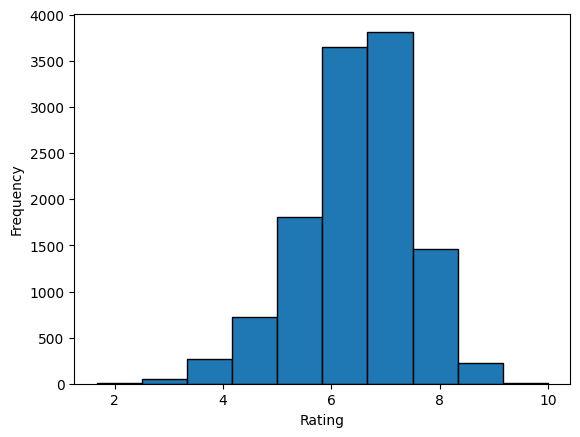

In [13]:
df['rating'].plot(kind='hist',bins=10,edgecolor='black')
plt.xlabel('Rating')

Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).

Convert categorical features into numerical representations if necessary.

Normalize numerical features if required.

In [15]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


From the dataset the best feature or features for computing similarities is genre and type.
- genre is the best feature for computing the similarities
- type is another good feature we can consider it or not.

Here i take 2 features genre and type.

In [21]:
## Conversion of categorical values into numerical
df['combined'] = df['genre'] + ' ' + df['type']
tfidf = TfidfVectorizer(stop_words='english')
matrix = tfidf.fit_transform(df['combined'])

I use the features genre and type , and tfidf already normalize the data. So there is no need for normalization.

Recommendation System:

Design a function to recommend anime based on cosine similarity.

Given a target anime, recommend a list of similar anime based on cosine similarity scores.

Experiment with different threshold values for similarity scores to adjust the recommendation list size.

Analyze the performance of the recommendation system and identify areas of improvement.

In [22]:
cosine = cosine_similarity(matrix)

In [23]:
cosine.shape

(12017, 12017)

In [26]:
## Checking the similarity of 1st index anime with others
cosine[0]

array([1.        , 0.13135073, 0.        , ..., 0.        , 0.        ,
       0.24003343])

The first value in the array is the similarity score of the 1st anime with itself. The other values are similarity score of other anime with 1st index anime.

In [28]:
df['name'].unique()

array(['Kimi no Na wa.', 'Fullmetal Alchemist: Brotherhood', 'Gintama°',
       ..., 'Violence Gekiga David no Hoshi',
       'Violence Gekiga Shin David no Hoshi: Inma Densetsu',
       'Yasuji no Pornorama: Yacchimae!!'], dtype=object)

In [39]:
def recommend_anime(anime_name):
    if anime_name in df['name'].values:
        index = df[df['name'] == anime_name].index[0]
        similar = sorted(list(enumerate(cosine[index])),reverse=True, key=lambda x: x[1])[1:6]
        print(f"Recommended anime like {anime_name} are")
        print("*" * 30)

        for anime in similar:
            print(df['name'].iloc[anime[0]])

    else:
        print(f"{anime_name} anime is not in the list")

In [40]:
recommend_anime('Gintama°')

Recommended anime like Gintama° are
******************************
Gintama&#039;
Gintama&#039;: Enchousen
Gintama
Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare
Gintama: Yorinuki Gintama-san on Theater 2D


In [41]:
## Experiment with different threshold values

In [44]:
def recommend_anime(anime_name, threshold=0.2):
    if anime_name in df['name'].values:
        index = df[df['name'] == anime_name].index[0]
        sim_scores = list(enumerate(cosine[index]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        print(f"Recommended anime like {anime_name} are")
        print("*" * 30)
        count = 0
        for anime in sim_scores[1:]:
            if anime[1] >= threshold:
                print(df['name'].iloc[anime[0]], "→ similarity:", round(anime[1], 3))
                count += 1

            if count == 10:
                break

        if count == 0:
            print("No recommendations found above threshold")

    else:
        print(f"{anime_name} anime is not in the list")

In [45]:
recommend_anime('Gintama°')

Recommended anime like Gintama° are
******************************
Gintama&#039; → similarity: 1.0
Gintama&#039;: Enchousen → similarity: 1.0
Gintama → similarity: 1.0
Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare → similarity: 0.942
Gintama: Yorinuki Gintama-san on Theater 2D → similarity: 0.942
Gintama Movie: Shinyaku Benizakura-hen → similarity: 0.942
Gintama: Shinyaku Benizakura-hen → similarity: 0.934
Gintama: Jump Festa 2014 Special → similarity: 0.934
Gintama: Nanigoto mo Saiyo ga Kanjin nano de Tasho Senobisuru Kurai ga Choudoyoi → similarity: 0.882
Gintama: Jump Festa 2015 Special → similarity: 0.849


In [46]:
## Analyze the performance of the recommendation system and identify areas of improvement.

Strength of the anime recommendation system
- Simple and efficient because i uses cosine similarity + TF-IDF which helps fast computation even for large datasets.
- Recommendations based on genre and type. the best features for similarity comparison
Areas for improvement
- If we can add more features, it improves recommendation quality
- If i use weighted features we get more realistic similarity


Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
2. What is collaborative filtering, and how does it work?

1.
- User-based collaborative filtering recommends items by identifying users with similar preferences and suggesting items they liked.  
- Item-based collaborative filtering recommends items by finding items similar to those the user has already interacted with.
- User-based methods focus on user similarity, while item-based methods focus on item similarity and are generally faster and more stable.

2.
Collaborative filtering is a recommendation technique that suggests items based on the preferences and behavior of similar users or items. The working is
- Collect user-item interaction data
- Find similarity between users or between items
- Recommend based on similarity